In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("E:\CSV files\heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

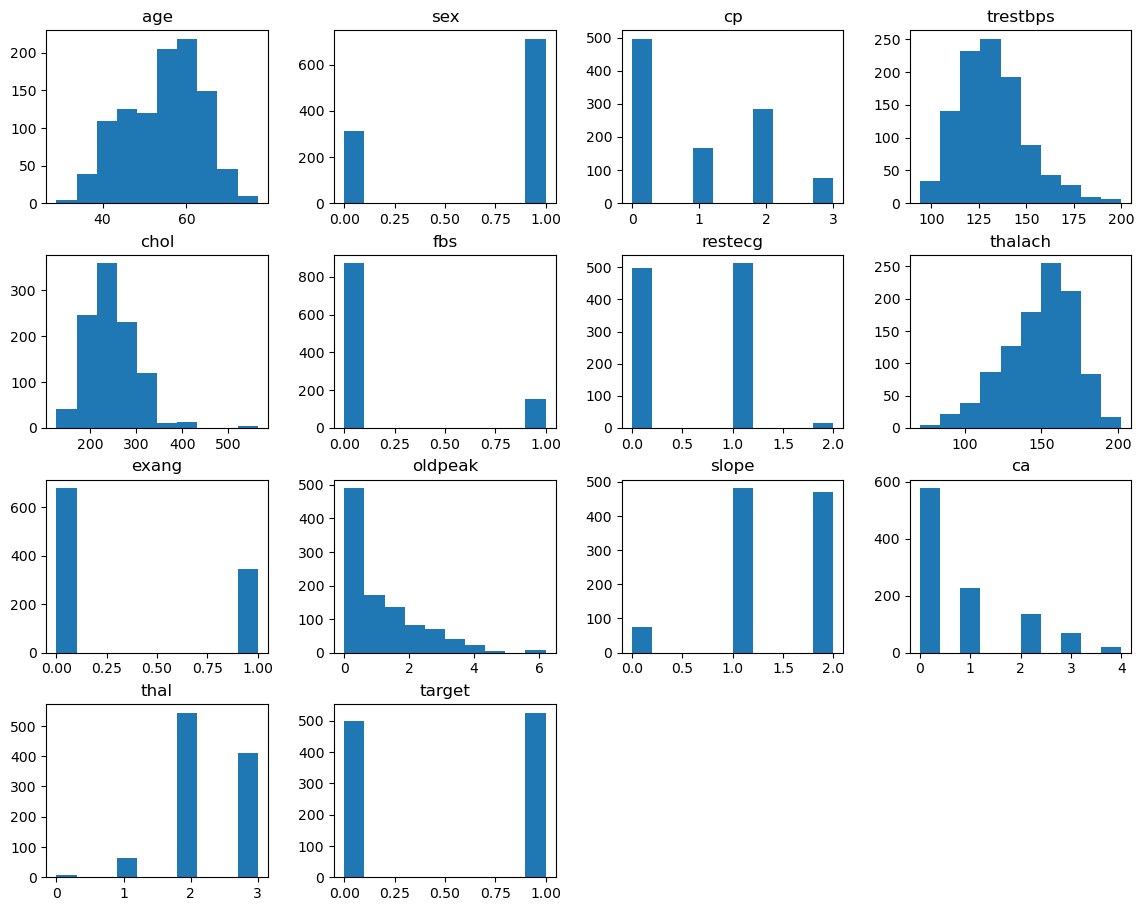

In [8]:
df.hist(
    figsize=(14,11),
    grid=False
)
plt.show()

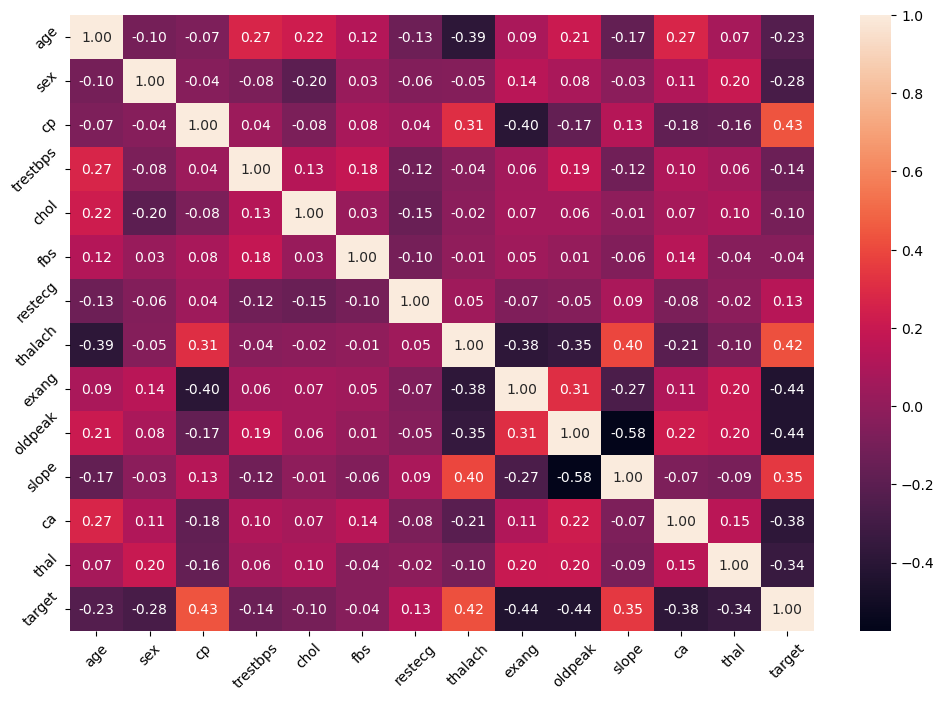

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(
    data=df.corr(),
    annot=True,
    fmt=".2f"
)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

In [16]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

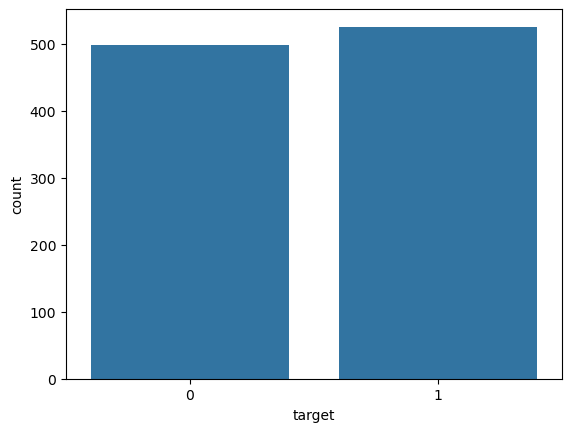

In [17]:
sns.countplot(
    data=df,
    x="target"
)
plt.show()

In [18]:
X=df.drop("target",axis=1)
y=df["target"]

In [19]:
X.shape

(1025, 13)

In [20]:
y.shape

(1025,)

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=22
)

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

base_model=DecisionTreeClassifier(max_depth=3)
model=BaggingClassifier(estimator=base_model,n_estimators=500)
model.fit(X_train,y_train)

,estimator,DecisionTreeC...r(max_depth=3)
,n_estimators,500
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [49]:
y_pred=model.predict(X_test)
y_pred

array([1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0])

In [50]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,precision_score,f1_score

print(f'Accuracy Score : {accuracy_score(y_test,y_pred)}')
print(f'Recall Score : {recall_score(y_test,y_pred)}')
print(f'Precision Score : {precision_score(y_test,y_pred)}')
print(f'F1 Score : {f1_score(y_test,y_pred)}')
print(f'Classification Report :\n{classification_report(y_test,y_pred)}')

Accuracy Score : 0.8443579766536965
Recall Score : 0.9323308270676691
Precision Score : 0.8
F1 Score : 0.8611111111111112
Classification Report :
              precision    recall  f1-score   support

           0       0.91      0.75      0.82       124
           1       0.80      0.93      0.86       133

    accuracy                           0.84       257
   macro avg       0.86      0.84      0.84       257
weighted avg       0.85      0.84      0.84       257



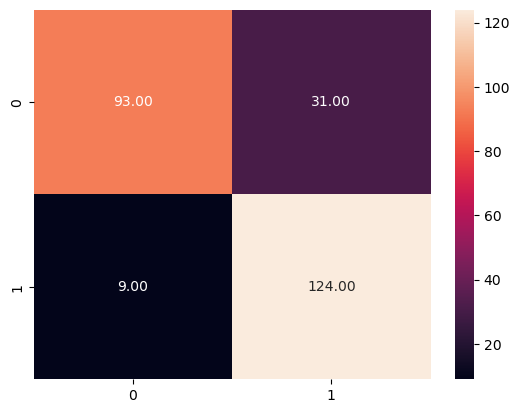

In [51]:
sns.heatmap(
    confusion_matrix(y_test,y_pred),
    annot=True,
    fmt=".2f"
)
plt.show()